In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
import pyarrow.parquet as pq
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score
from google.colab import files

plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)

In [ ]:
path = kagglehub.dataset_download("anlgrbz/student-demographics-online-education-dataoulad")
print("Caminho dos arquivos baixados:", path)

Using Colab cache for faster access to the 'student-demographics-online-education-dataoulad' dataset.
Caminho dos arquivos baixados: /kaggle/input/student-demographics-online-education-dataoulad


In [ ]:
student_info   = pd.read_csv(os.path.join(path,'studentInfo.csv'))
student_assess = pd.read_csv(os.path.join(path,'studentAssessment.csv'))
student_vle  = pd.read_csv(os.path.join(path,'studentVle.csv'))
assessments = pd.read_csv(os.path.join(path,'assessments.csv'))
vle = pd.read_csv(os.path.join(path,'vle.csv'))

In [ ]:
#student info
student_info.shape
student_info.info()
student_info.isnull().sum()
student_info.duplicated().sum()
student_info.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   code_module           32593 non-null  object
 1   code_presentation     32593 non-null  object
 2   id_student            32593 non-null  int64 
 3   gender                32593 non-null  object
 4   region                32593 non-null  object
 5   highest_education     32593 non-null  object
 6   imd_band              31482 non-null  object
 7   age_band              32593 non-null  object
 8   num_of_prev_attempts  32593 non-null  int64 
 9   studied_credits       32593 non-null  int64 
 10  disability            32593 non-null  object
 11  final_result          32593 non-null  object
dtypes: int64(3), object(9)
memory usage: 3.0+ MB


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


In [ ]:
#student assessment
student_assess.shape
student_assess.info()
student_assess.isnull().sum()
student_assess.duplicated().sum()
student_assess.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173912 entries, 0 to 173911
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id_assessment   173912 non-null  int64  
 1   id_student      173912 non-null  int64  
 2   date_submitted  173912 non-null  int64  
 3   is_banked       173912 non-null  int64  
 4   score           173739 non-null  float64
dtypes: float64(1), int64(4)
memory usage: 6.6 MB


,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0
3,1752,32885,26,0,69.0
4,1752,38053,19,0,79.0


In [ ]:
#assessment
assessments.shape
assessments.info()
assessments.duplicated().sum()
assessments.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   code_module        206 non-null    object 
 1   code_presentation  206 non-null    object 
 2   id_assessment      206 non-null    int64  
 3   assessment_type    206 non-null    object 
 4   date               195 non-null    float64
 5   weight             206 non-null    float64
dtypes: float64(2), int64(1), object(3)
memory usage: 9.8+ KB


,code_module,code_presentation,id_assessment,assessment_type,date,weight
0,AAA,2013J,1752,TMA,19.0,10.0
1,AAA,2013J,1753,TMA,54.0,20.0
2,AAA,2013J,1754,TMA,117.0,20.0
3,AAA,2013J,1755,TMA,166.0,20.0
4,AAA,2013J,1756,TMA,215.0,30.0


In [ ]:
#student vle
student_vle.shape
student_vle.info()
student_vle.isnull().sum()
student_vle.duplicated().sum()
student_vle.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10655280 entries, 0 to 10655279
Data columns (total 6 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   code_module        object
 1   code_presentation  object
 2   id_student         int64 
 3   id_site            int64 
 4   date               int64 
 5   sum_click          int64 
dtypes: int64(4), object(2)
memory usage: 487.8+ MB


,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1


In [ ]:
#VLE
vle.shape
vle.info()
vle.isnull().sum()
vle.duplicated().sum()
vle.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6364 entries, 0 to 6363
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_site            6364 non-null   int64  
 1   code_module        6364 non-null   object 
 2   code_presentation  6364 non-null   object 
 3   activity_type      6364 non-null   object 
 4   week_from          1121 non-null   float64
 5   week_to            1121 non-null   float64
dtypes: float64(2), int64(1), object(3)
memory usage: 298.4+ KB


,id_site,code_module,code_presentation,activity_type,week_from,week_to
0,546943,AAA,2013J,resource,NaN,NaN
1,546712,AAA,2013J,oucontent,NaN,NaN
2,546998,AAA,2013J,resource,NaN,NaN
3,546888,AAA,2013J,url,NaN,NaN
4,547035,AAA,2013J,resource,NaN,NaN


In [ ]:
# 1. base: studentInfo (demographics)
df = student_info.merge(student_assess,on='id_student',how='left')
# merge com os testes
df = df.merge(assessments,on=['id_assessment', 'code_module', 'code_presentation'],how='left')
# merge com interação dos estudantes
student_vle_agg = student_vle.groupby(['id_student', 'code_module', 'code_presentation'])['sum_click'].sum().reset_index()
df = df.merge(student_vle_agg,on=['id_student', 'code_module', 'code_presentation'],how='left')

In [ ]:
df.columns

Index(['code_module', 'code_presentation', 'id_student', 'gender', 'region',
       'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts',
       'studied_credits', 'disability', 'final_result', 'id_assessment',
       'date_submitted', 'is_banked', 'score', 'assessment_type', 'date',
       'weight', 'sum_click'],
      dtype='object')

In [ ]:
df.to_csv('oulad.csv')

In [ ]:
from google.colab import files

files.download('oulad.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df = pd.read_csv('oulad.csv')

In [ ]:
df = df.drop(columns=['Unnamed: 0'])

In [ ]:
df.columns

Index(['code_module', 'code_presentation', 'id_student', 'gender', 'region',
       'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts',
       'studied_credits', 'disability', 'final_result', 'id_assessment',
       'date_submitted', 'is_banked', 'score', 'assessment_type', 'date',
       'weight', 'sum_click'],
      dtype='object')

In [ ]:
df.describe()

,id_student,num_of_prev_attempts,studied_credits,id_assessment,date_submitted,is_banked,score,date,weight,sum_click
count,2.131660e+05,213166.000000,213166.000000,207319.000000,207319.000000,207319.000000,207092.000000,171047.000000,173912.000000,207559.000000
mean,7.044264e+05,0.157352,78.447360,26708.371727,114.501493,0.017119,75.402459,130.605623,12.743899,1868.933797
std,5.497525e+05,0.462271,38.360626,8428.225700,72.473110,0.129713,19.081310,78.025175,17.877301,1990.611045
min,3.733000e+03,0.000000,30.000000,1752.000000,-11.000000,0.000000,0.000000,12.000000,0.000000,1.000000
25%,5.069300e+05,0.000000,60.000000,24284.000000,50.000000,0.000000,65.000000,54.000000,0.000000,532.000000
50%,5.856620e+05,0.000000,60.000000,25357.000000,114.000000,0.000000,79.000000,129.000000,9.000000,1205.000000
75%,6.336090e+05,0.000000,90.000000,34881.000000,172.000000,0.000000,89.000000,214.000000,18.000000,2549.000000
max,2.716795e+06,6.000000,655.000000,37443.000000,608.000000,1.000000,100.000000,261.000000,100.000000,24139.000000


In [ ]:
df['age_band'].value_counts()

,count
age_band,
0-35,147675
35-55,63927
55<=,1564


In [ ]:
df['gender'].value_counts()

,count
gender,
M,121864
F,91302


In [ ]:
df['highest_education'].value_counts()

,count
highest_education,
A Level or Equivalent,97550
Lower Than A Level,76668
HE Qualification,34479
Post Graduate Qualification,2739
No Formal quals,1730


In [ ]:
df['final_result'].value_counts()

,count
final_result,
Pass,118027
Fail,34173
Withdrawn,30622
Distinction,30344


In [ ]:
df.isnull().sum()

,0
code_module,0
code_presentation,0
id_student,0
gender,0
region,0
highest_education,0
imd_band,9413
age_band,0
num_of_prev_attempts,0
studied_credits,0


In [ ]:
df.loc[df.duplicated(subset=['age_band'])].head(10)

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,id_assessment,date_submitted,is_banked,score,assessment_type,date,weight,sum_click
1,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,1753.0,53.0,0.0,85.0,TMA,54.0,20.0,934.0
2,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,1754.0,115.0,0.0,80.0,TMA,117.0,20.0,934.0
3,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,1755.0,164.0,0.0,85.0,TMA,166.0,20.0,934.0
4,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,1756.0,212.0,0.0,82.0,TMA,215.0,30.0,934.0
6,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,1753.0,52.0,0.0,68.0,TMA,54.0,20.0,1435.0
7,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,1754.0,121.0,0.0,70.0,TMA,117.0,20.0,1435.0
8,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,1755.0,164.0,0.0,64.0,TMA,166.0,20.0,1435.0
9,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,1756.0,212.0,0.0,60.0,TMA,215.0,30.0,1435.0
10,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,NaN,NaN,NaN,NaN,NaN,NaN,NaN,281.0
11,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,1752.0,17.0,0.0,72.0,TMA,19.0,10.0,2158.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 213166 entries, 0 to 213165
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   code_module           213166 non-null  object 
 1   code_presentation     213166 non-null  object 
 2   id_student            213166 non-null  int64  
 3   gender                213166 non-null  object 
 4   region                213166 non-null  object 
 5   highest_education     213166 non-null  object 
 6   imd_band              203753 non-null  object 
 7   age_band              213166 non-null  object 
 8   num_of_prev_attempts  213166 non-null  int64  
 9   studied_credits       213166 non-null  int64  
 10  disability            213166 non-null  object 
 11  final_result          213166 non-null  object 
 12  id_assessment         207319 non-null  float64
 13  date_submitted        207319 non-null  float64
 14  is_banked             207319 non-null  float64
 15  

In [ ]:
pd.crosstab(df['gender'] , df['final_result'])

final_result,Distinction,Fail,Pass,Withdrawn
gender,,,,
F,13130,14710,51456,12006
M,17214,19463,66571,18616


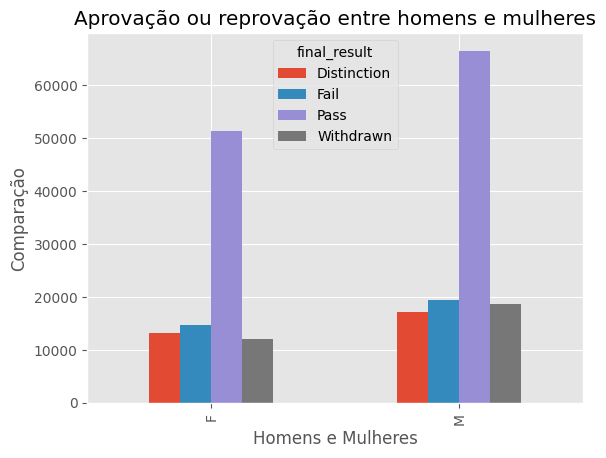

In [ ]:
ax = pd.crosstab(df['gender'], df['final_result']).plot(kind='bar', title='Aprovação ou reprovação entre homens e mulheres')
ax = plt.xlabel('Homens e Mulheres')
ax = plt.ylabel('Comparação')

In [ ]:
pd.crosstab(df['age_band'], df['final_result'])

final_result,Distinction,Fail,Pass,Withdrawn
age_band,,,,
0-35,18767,25364,81717,21827
35-55,11173,8671,35499,8584
55<=,404,138,811,211


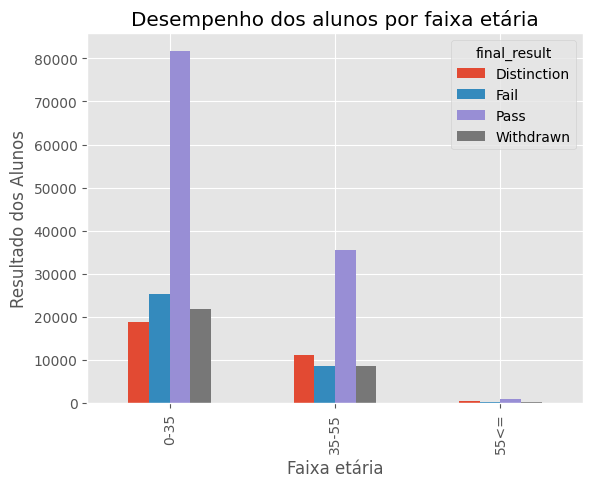

In [ ]:
ax = pd.crosstab(df['age_band'], df['final_result']).plot(kind='bar', title='Desempenho dos alunos por faixa etária')
ax = plt.xlabel('Faixa etária')
ax = plt.ylabel('Resultado dos Alunos')

In [ ]:
df.groupby('final_result') ['sum_click'].mean()

,sum_click
final_result,
Distinction,2864.718264
Fail,1088.750394
Pass,2090.946211
Withdrawn,688.694729


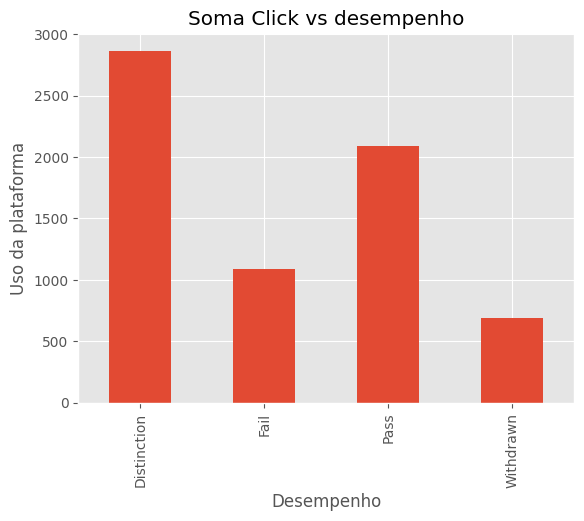

In [ ]:
ax = df.groupby('final_result') ['sum_click'].mean().plot(kind ='bar', title='Soma Click vs desempenho')
ax = plt.xlabel('Desempenho')
ax = plt.ylabel('Uso da plataforma')

In [ ]:
df.groupby('age_band')['score'].mean()

,score
age_band,
0-35,74.551903
35-55,77.253011
55<=,79.572172


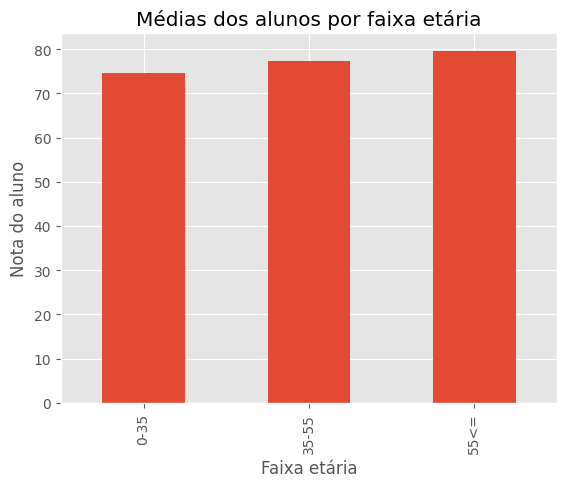

In [ ]:
ax = df.groupby('age_band') ['score'].mean().plot(kind ='bar', title='Médias dos alunos por faixa etária')
ax = plt.xlabel('Faixa etária')
ax = plt.ylabel('Nota do aluno')

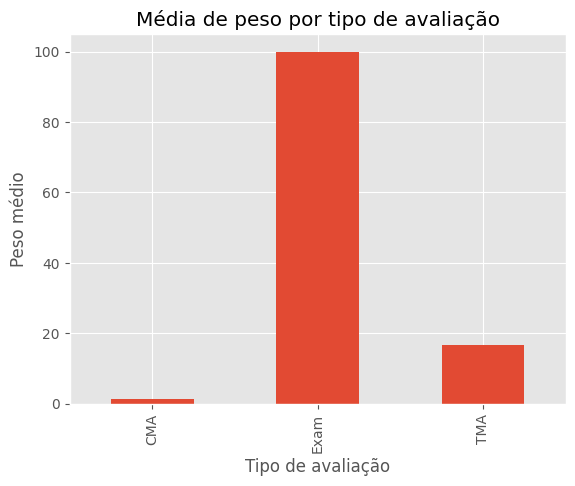

In [ ]:
ax = df.groupby('assessment_type')['weight'].mean()
ax = ax.plot(kind='bar', title='Média de peso por tipo de avaliação')
ax = plt.xlabel('Tipo de avaliação')
ax = plt.ylabel('Peso médio')

* 0.00 a ±0.19 → muito fraca ou quase nenhuma correlação
* ±0.20 a ±0.39 → fraca
* ±0.40 a ±0.59 → moderada
* ±0.60 a ±0.79 → forte
* ±0.80 a ±1.00 → muito forte

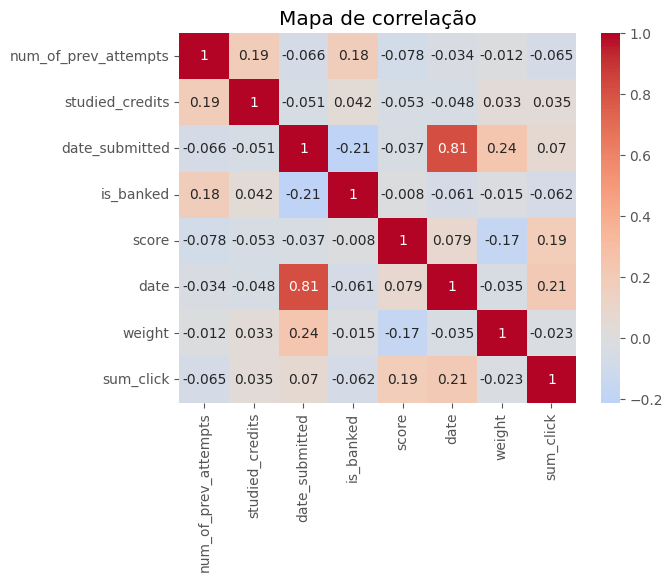

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

colunas = df.select_dtypes(include = ['int64', 'float64']).columns
colunas = colunas.drop(['id_student', 'id_assessment'], errors= 'ignore')
df_corr = df[colunas].corr()

sns.heatmap(df_corr, annot=True, cmap = 'coolwarm', center = 0)
plt.title('Mapa de correlação')
plt.show()